# RF/FM Data Loading & Diagnostics


In [1]:
import pandas as pd
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import ast
import sys

## 1. Load All CSV Files

In [2]:
archivos = glob.glob("DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv")
datos_nodos = {}

EXCLUDE = {
  #  "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota",
  #  "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota",
  #  "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node9-Funza",
  #  "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota",
}

load_errors = []

for archivo in tqdm(archivos, desc="Loading CSV data"):
    nombre_nodo = archivo.replace('\\', '/').replace('.csv', '')

    if nombre_nodo in EXCLUDE:
        print(f"⏭️  Skipped: {nombre_nodo}")
        continue

    try:
        df = pd.read_csv(archivo, encoding='utf-8-sig')
    except Exception as e:
        print(f"❌ Failed to load {archivo}: {e}")
        load_errors.append({'file': archivo, 'error': str(e)})
        continue

    df = df.reset_index(drop=True)

    # NaN handling ──────────────────────────────────────────────
    n_before = len(df)
    if 'pxx' in df.columns:
        null_mask = df['pxx'].isnull()
        if null_mask.any():
            print(f"⚠️  {nombre_nodo}: {null_mask.sum()} null 'pxx' rows dropped (out of {n_before})")
            df = df[~null_mask].reset_index(drop=True)

    # Duplicate row detection ──────────────────────────────────
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"⚠️  {nombre_nodo}: {dupes} duplicate rows removed")
        df = df.drop_duplicates().reset_index(drop=True)

    # ─ Validate pxx across ALL rows  ─────────────
    if 'pxx' in df.columns:
        bad_rows = []
        parsed_arrays = []
        for idx, val in df['pxx'].items():
            try:
                arr = np.array(ast.literal_eval(val))
                parsed_arrays.append((idx, arr))
            except (ValueError, SyntaxError) as e:
                bad_rows.append(idx)

        if bad_rows:
            print(f"  {nombre_nodo}: {len(bad_rows)} rows with malformed 'pxx' dropped → indices: {bad_rows[:10]}{'...' if len(bad_rows) > 10 else ''}")
            df = df.drop(index=bad_rows).reset_index(drop=True)
            # Rebuild parsed_arrays without bad rows
            parsed_arrays = [(i, np.array(ast.literal_eval(v)))
                             for i, v in df['pxx'].items()]

        #  pxx array length consistency ─────────────────────────
        if parsed_arrays:
            lengths = [arr.shape[0] for _, arr in parsed_arrays]
            unique_lengths = set(lengths)
            if len(unique_lengths) > 1:
                expected_len = max(set(lengths), key=lengths.count)  # majority vote
                bad_len_indices = [idx for (idx, arr) in parsed_arrays
                                   if arr.shape[0] != expected_len]
                print(f" {nombre_nodo}: inconsistent pxx lengths {unique_lengths}. "
                      f"Dropping {len(bad_len_indices)} rows with unexpected lengths.")
                df = df.drop(index=bad_len_indices).reset_index(drop=True)
            else:
                expected_len = unique_lengths.pop()

        # ──  pxx value range validation per node ──────────────────
            all_vals = np.concatenate([arr for _, arr in parsed_arrays
                                       if arr.shape[0] == expected_len])
            pxx_min, pxx_max = all_vals.min(), all_vals.max()
            display_name = nombre_nodo.split('/')[-1]
            print(f"   📡 {display_name}: pxx range [{pxx_min:.2f}, {pxx_max:.2f}] "
                  f"| array length: {expected_len} | rows: {len(df)}")

    datos_nodos[nombre_nodo] = df

if load_errors:
    print(f"\n {len(load_errors)} file(s) failed to load:")
    for e in load_errors:
        print(f"   {e['file']}: {e['error']}")

Loading CSV data: 100%|██████████| 10/10 [04:03<00:00, 24.33s/it]   📡 Node9-Funza: pxx range [-28.16, 13.03] | array length: 32768 | rows: 105



## 2. Dataset Summary Report

In [3]:
if not datos_nodos:
    print(" No nodes loaded. Check file paths and load errors above.")
else:
    print(f"\n Dataset Summary Report")
    print("=" * 70)

    # ── 1. Per-Node Shape Information ─────────────────────────────────────
    print(f"\n Per-Node DataFrame Shapes:")
    print(f"{'Node Name':<50} {'Rows':>8} {'Cols':>6} {'Memory (MB)':>12}")
    print("-" * 70)

    node_shapes = {}
    total_rows = 0
    total_memory_bytes = 0

    for nombre_nodo, df in sorted(datos_nodos.items()):
        rows, cols = df.shape
        #  Cache memory calculation — avoid calling it twice
        memory_bytes = df.memory_usage(deep=True).sum()
        memory_mb = memory_bytes / (1024 ** 2)

        node_shapes[nombre_nodo] = {'rows': rows, 'cols': cols}
        total_rows += rows
        total_memory_bytes += memory_bytes

        display_name = nombre_nodo.split('/')[-1] if '/' in nombre_nodo else nombre_nodo
        print(f"{display_name:<50} {rows:>8} {cols:>6} {memory_mb:>12.2f}")

    # ── 2. Aggregate Statistics ───────────────────────────────────────────
    print(f"\n Aggregate Statistics:")
    print(f"   • Total nodes loaded:     {len(datos_nodos)}")
    print(f"   • Total records (rows):   {total_rows:,}")
    print(f"   • Total memory usage:     {total_memory_bytes / (1024**2):.2f} MB")
    max_rows = max(shape['rows'] for shape in node_shapes.values())
    print(f"   • Maximum rows: {max_rows}")
    row_counts = [shape['rows'] for shape in node_shapes.values()]
    mode_series = pd.Series(row_counts).mode()
    mode_rows = mode_series.iloc[0] if not mode_series.empty else None
    print(f"   • Mode rows: {mode_rows}")
    # ── 3. Column Consistency Check ───────────────────────────────────────
    print(f"\n Column Consistency:")
    all_columns = [set(df.columns) for df in datos_nodos.values()]
    if len(set(frozenset(c) for c in all_columns)) == 1:
        first_df = next(iter(datos_nodos.values()))
        print(f"    All nodes have identical columns: {list(first_df.columns)}")
    else:
        print(f"     Column mismatch detected!")
        for nombre_nodo, df in datos_nodos.items():
            print(f"      {nombre_nodo}: {list(df.columns)}")

    # ── 4. Data Type & Sample Preview ─────────────────────────────────────
    # irst_node is now safely scoped inside the `if datos_nodos` block
    first_node = next(iter(datos_nodos.values()))

    print(f"\n Sample Data Structure (first node, first row):")
    print(f"   Columns: {list(first_node.columns)}")
    print(f"   Data types:\n{first_node.dtypes}")

    if 'pxx' in first_node.columns and len(first_node) > 0:
        sample_pxx = first_node['pxx'].iloc[0]
        pxx_array = np.array(ast.literal_eval(sample_pxx))
        print(f"\n   'pxx' sample (row 0):")
        print(f"      • Raw string length: {len(sample_pxx)} chars")
        print(f"      • Parsed array shape: {pxx_array.shape}")
        print(f"      • Value range: [{pxx_array.min():.2f}, {pxx_array.max():.2f}]")

    # ── 5. Row Index Range Validation ─────────────────────────────────────
    print(f"\n Row Index Ranges (for data_record selection):")
    index_ranges = {}
    for nombre_nodo, df in datos_nodos.items():
        min_idx, max_idx = df.index.min(), df.index.max()
        index_ranges[nombre_nodo] = (min_idx, max_idx)
        display_name = nombre_nodo.split('/')[-1]
        print(f"   {display_name:<30} [{min_idx}, {max_idx}]")

    global_min = max(r[0] for r in index_ranges.values())
    global_max = min(r[1] for r in index_ranges.values())
    print(f"\n   Safe data_record range for ALL nodes: [{global_min}, {global_max}]")


 Dataset Summary Report

 Per-Node DataFrame Shapes:
Node Name                                              Rows   Cols  Memory (MB)
----------------------------------------------------------------------
Node1-Bogota                                            105     16        63.87
Node10-Bogota                                           104     16        63.24
Node2-Bogota                                            105     16        63.82
Node3-Bogota                                            105     16        63.87
Node4-Bogota                                            105     16        63.85
Node5-Bogota                                            105     16        63.86
Node6-Bogota                                            105     16        63.87
Node7-Bogota                                            105     16        63.85
Node8-Bogota                                             23     16        13.99
Node9-Funza                                             105     16        6

## 3. Visual and Export Summary

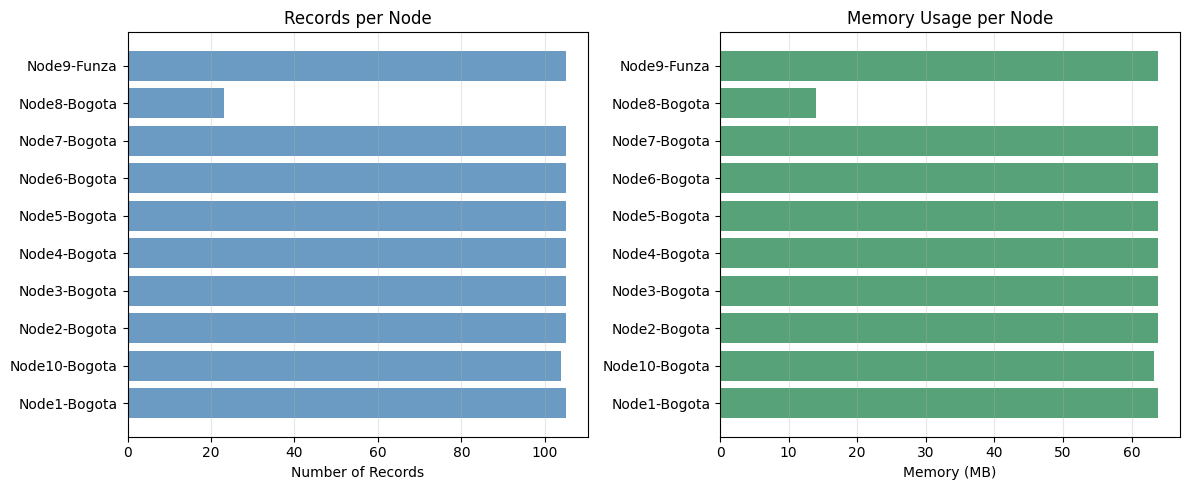

In [4]:
# ── Record Integrity Visualization ─────────────────────────────────────

if datos_nodos and len(datos_nodos) > 1:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    node_labels = [n.split('/')[-1] for n in node_shapes.keys()]
    row_counts = [s['rows'] for s in node_shapes.values()]
    plt.barh(node_labels, row_counts, color='steelblue', alpha=0.8)
    plt.xlabel("Number of Records")
    plt.title("Records per Node")
    plt.grid(axis='x', alpha=0.3)

# ── Memory Usage Visualization ─────────────────────────────────────
    plt.subplot(1, 2, 2)
    memory_vals = [df.memory_usage(deep=True).sum() / (1024**2) for df in datos_nodos.values()]
    plt.barh(node_labels, memory_vals, color='seagreen', alpha=0.8)
    plt.xlabel("Memory (MB)")
    plt.title("Memory Usage per Node")
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [5]:
if datos_nodos:
    data_summary = {
        'timestamp': pd.Timestamp.now().isoformat(),
        'n_nodes': len(datos_nodos),
        'total_records': total_rows,
        'total_memory_mb': total_memory_bytes / (1024**2),
        'node_shapes': node_shapes,
        'safe_row_range': (global_min, global_max),
        'columns': list(first_node.columns),
        'excluded_nodes': list(EXCLUDE),
        'load_errors': load_errors,
    }

    print(f" Summary dictionary stored in 'data_summary'")
    print(f"    timestamp → {data_summary['timestamp']}")
    print(f"    n_nodes → {data_summary['n_nodes']}")
    #print(f"    node_shapes → {data_summary['node_shapes']}")
    #print(f"    columns → {data_summary['columns']}")
    print(f"    excluded_nodes → {data_summary['excluded_nodes']}")
    print(f"    load_errors → {data_summary['load_errors']}")
    print(f"    safe_row_range → {data_summary['safe_row_range']}")
    row_counts = [s['rows'] for s in node_shapes.values()]
    mode_rows = pd.Series(row_counts).mode().iloc[0]
    outlier_nodes = {k: v['rows'] for k, v in node_shapes.items()
                 if v['rows'] < mode_rows * 0.5}
    if outlier_nodes:
        print(f"      • Row-count outliers detected: {outlier_nodes}")
        print(f"      • safe_row_range is capped to {global_max} — consider excluding outlier nodes.")
    
    print(f"      • Mode of rows: {mode_rows}")
    print(f"    Value range → [{pxx_array.min():.2f}, {pxx_array.max():.2f}]")
else:
    data_summary = {}
    print("  data_summary is empty — no nodes were loaded successfully.")

 Summary dictionary stored in 'data_summary'
    timestamp → 2026-03-08T13:59:13.447300
    n_nodes → 10
    excluded_nodes → []
    load_errors → []
    safe_row_range → (0, 22)
      • Row-count outliers detected: {'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota': 23}
      • safe_row_range is capped to 22 — consider excluding outlier nodes.
      • Mode of rows: 105
    Value range → [-24.51, 5.74]


### PSD diagnostics: 

#### Parameter histogram shape analysis

Parsing pxx across 10 nodes...
100%|██████████| 10/10 [03:17<00:00, 19.75s/it]
/tmp/ipykernel_51/1476032786.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_51/1476032786.py:115: UserWarning: The figure layout has changed to tight
  plt.tight_layout()

 Parsed 31,686,656 values total
  7,977 values (0.03%) fall outside GLOBAL_RANGE (-27, 6) — adjust if needed


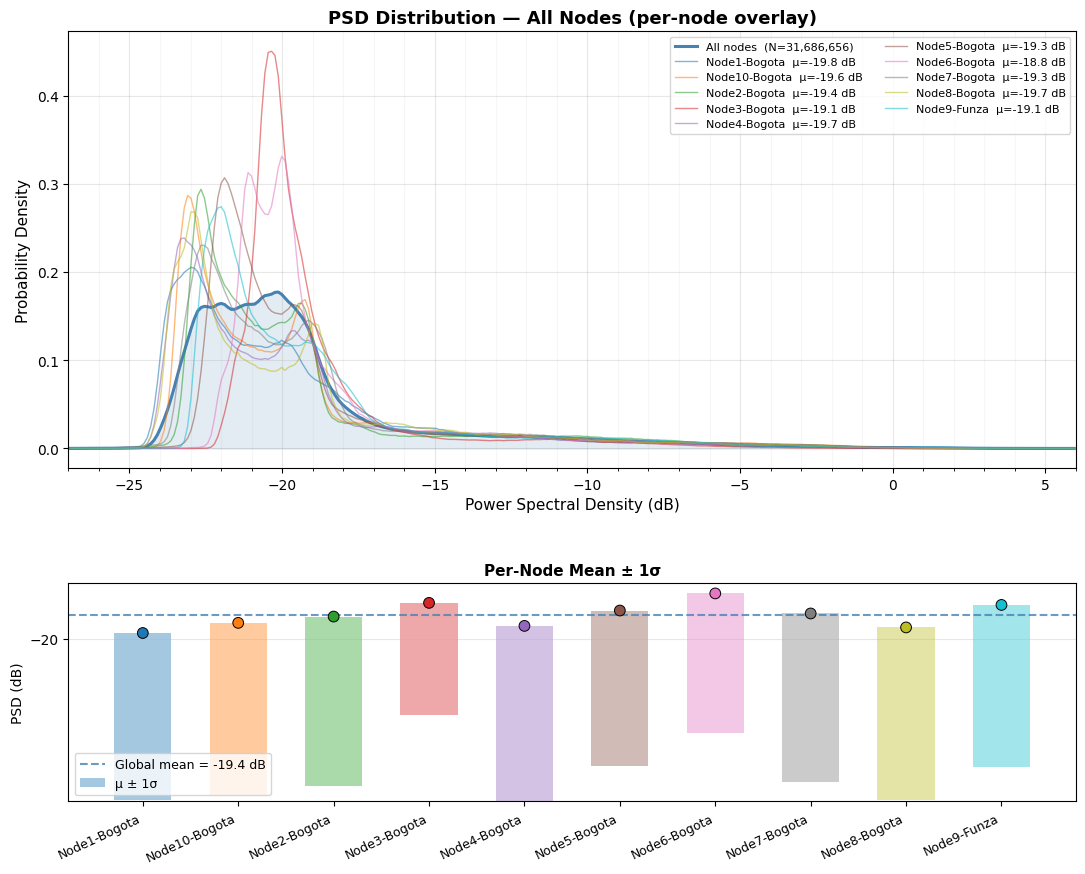


Node                  Mean (dB)   Std (dB)   Rows       Values
--------------------------------------------------------------
Node1-Bogota             -19.85       4.29    105    3,439,202
Node10-Bogota            -19.59       4.42    104    3,407,148
Node2-Bogota             -19.43       4.35    105    3,439,350
Node3-Bogota             -19.08       2.87    105    3,439,687
Node4-Bogota             -19.67       4.50    105    3,440,516
Node5-Bogota             -19.27       3.98    105    3,440,039
Node6-Bogota             -18.83       3.59    105    3,440,031
Node7-Bogota             -19.35       4.32    105    3,438,978
Node8-Bogota             -19.71       4.42     23      753,371
Node9-Funza              -19.13       4.17    105    3,440,357
--------------------------------------------------------------
GLOBAL                   -19.39       0.30          31,686,656


In [6]:
### Pxx Histogram Estimation
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────
N_BINS       = 300          # histogram resolution
#GLOBAL_RANGE = (pxx_array.min(), pxx_array.max())    # dB window — adjust if data falls outside
GLOBAL_RANGE = (-27, 6)
ALPHA_NODE   = 0.55         # per-node line opacity

# Node display order (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# ── Step 1: Parse pxx and accumulate ──────────────────────────────────────
# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

global_counts = np.zeros(N_BINS, dtype=np.int64)   # aggregated across all nodes
node_counts   = {}                                  # per-node histogram counts
node_stats    = {}                                  # mean / std per node

total_values = 0
clipped      = 0  # values outside GLOBAL_RANGE

print(f"Parsing pxx across {N_NODES} nodes...")
for node_key, label in tqdm(zip(NODE_NAMES, NODE_LABELS), total=N_NODES):
    df   = datos_nodos[node_key]
    arrs = []

    for val in df['pxx']:
        # pxx may already be a parsed array (numpy) or still a string
        if isinstance(val, str):
            arr = np.array(ast.literal_eval(val), dtype=np.float32)
        else:
            arr = np.asarray(val, dtype=np.float32)
        arrs.append(arr)

    flat = np.concatenate(arrs)                    # shape: (n_rows × 32768,)
    total_values += flat.size
    clipped      += np.sum((flat < GLOBAL_RANGE[0]) | (flat > GLOBAL_RANGE[1]))

    counts, _ = np.histogram(flat, bins=bin_edges)
    node_counts[label]   = counts
    global_counts       += counts
    node_stats[label]    = {'mean': float(np.mean(flat)), 'std': float(np.std(flat))}

print(f"\n Parsed {total_values:,} values total")
if clipped:
    pct = 100 * clipped / total_values
    print(f"  {clipped:,} values ({pct:.2f}%) fall outside GLOBAL_RANGE {GLOBAL_RANGE} — adjust if needed")

# ── Step 2: Normalise to probability density ──────────────────────────────
bin_width      = bin_edges[1] - bin_edges[0]
global_density = global_counts / (global_counts.sum() * bin_width)
node_densities = {
    lbl: c / (c.sum() * bin_width)
    for lbl, c in node_counts.items()
}

# ── Step 3: Plot ───────────────────────────────────────────────────────────
cmap   = plt.cm.tab10
colors = [cmap(i / max(N_NODES - 1, 1)) for i in range(N_NODES)]

fig, axes = plt.subplots(2, 1, figsize=(13, 10),
                          gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35},
                          layout='constrained')
# ── Panel A: Global + per-node overlay ────────────────────────────────────
ax = axes[0]
ax.fill_between(bin_centers, global_density, alpha=0.15, color='steelblue', label='_nolegend_')
ax.plot(bin_centers, global_density, color='steelblue', lw=2.2,
        label=f'All nodes  (N={total_values:,})')

for (lbl, density), color in zip(node_densities.items(), colors):
    mu  = node_stats[lbl]['mean']
    ax.plot(bin_centers, density, lw=1.0, alpha=ALPHA_NODE,
            color=color, label=f"{lbl}  μ={mu:.1f} dB")

ax.set_xlim(GLOBAL_RANGE)
ax.set_xlabel('Power Spectral Density (dB)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('PSD Distribution — All Nodes (per-node overlay)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.1)

# ── Panel B: Mean ± 1σ per node (compact stats) ───────────────────────────
ax2    = axes[1]
labels = list(node_stats.keys())
means  = np.array([node_stats[l]['mean'] for l in labels])
stds   = np.array([node_stats[l]['std']  for l in labels])
xs     = np.arange(len(labels))

ax2.bar(xs, stds, bottom=means - stds, alpha=0.4, color=colors, width=0.6, label='μ ± 1σ')
ax2.scatter(xs, means, color=colors, zorder=5, s=60, edgecolors='black', lw=0.7)
ax2.axhline(np.mean(means), color='steelblue', lw=1.5, ls='--', alpha=0.8,
            label=f'Global mean = {np.mean(means):.1f} dB')

ax2.set_xticks(xs)
ax2.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('PSD (dB)', fontsize=10)
ax2.set_title('Per-Node Mean ± 1σ', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax2.grid(True, axis='y', alpha=0.3)

#plt.suptitle('FM Band PSD Histogram  |  Bogotá–Funza Nodes  |  88–108 MHz',
#             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Step 4: Print stats table ──────────────────────────────────────────────
print(f"\n{'Node':<20} {'Mean (dB)':>10} {'Std (dB)':>10} {'Rows':>6} {'Values':>12}")
print('-' * 62)
for lbl in labels:
    n_rows = len(datos_nodos[
        next(k for k in NODE_NAMES if k.endswith(lbl))
    ])
    n_vals = node_counts[lbl].sum()
    print(f"{lbl:<20} {node_stats[lbl]['mean']:>10.2f} {node_stats[lbl]['std']:>10.2f} {n_rows:>6} {n_vals:>12,}")
print('-' * 62)
print(f"{'GLOBAL':<20} {np.mean(means):>10.2f} {float(np.std(means)):>10.2f} {'':>6} {total_values:>12,}")

In [7]:
# ── Correlation Matrix of PSD Histogram Shapes ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import pearsonr

# Stack all per-node density curves into a matrix: shape (N_NODES, N_BINS)
density_matrix = np.stack([node_densities[lbl] for lbl in NODE_LABELS])

# Compute pairwise Pearson correlation between histogram shapes
corr_matrix = np.corrcoef(density_matrix)   # shape (N_NODES, N_NODES)

# ── Row-wise sum of the correlation matrix ─────────────────────────────────
# Each row i sums all Pearson r values between node i and every other node.
# Higher sum → node whose histogram shape is more similar to the rest.

row_sums = corr_matrix.sum(axis=1)          # shape: (N_NODES,)
# Subtract self-correlation (diagonal = 1.0) to get cross-node score only
cross_sums = row_sums - 1.0

# Rank by cross-node similarity
ranked = sorted(zip(NODE_LABELS, cross_sums), key=lambda x: x[1], reverse=True)
print(f"\n📊 Ranked by cross-node similarity:")
for rank, (label, cs) in enumerate(ranked, 1):
    flag = '  ⚠️  outlier' if cs < (cross_sums.mean() - cross_sums.std()) else ''
    print(f"  {rank}. {label:<22} Σr = {cs:.4f}{flag}")



📊 Ranked by cross-node similarity:
  1. Node7-Bogota           Σr = 7.5263
  2. Node2-Bogota           Σr = 7.3478
  3. Node10-Bogota          Σr = 7.1110
  4. Node1-Bogota           Σr = 7.0806
  5. Node4-Bogota           Σr = 6.9903
  6. Node9-Funza            Σr = 6.8889
  7. Node8-Bogota           Σr = 6.7255
  8. Node5-Bogota           Σr = 6.6630
  9. Node6-Bogota           Σr = 5.5784  ⚠️  outlier
  10. Node3-Bogota           Σr = 5.0046  ⚠️  outlier


| Goal | Minimum Spacing | Preferred Spacing |
|------|----------------|-------------------|
| Basic diversity (omni) | 0.75 m (¼ λ @ 88 MHz) | 1.5–3.0 m (½–1 λ) |
| High isolation / low coupling | 2.8 m | 7.6 m |
| Research-grade spatial independence | 3–6 m (urban) | 10–15 m (open) |
| Your Bogotá–Funza network | Already satisfied (nodes are km apart) | Focus on temporal alignment & calibration |

In [8]:
print("nodes to be excluded:", 'node6,node3')

nodes to be excluded: node8,node5,node6,node3


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>